In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

plt.rcParams.update({'font.size': 16})

In [2]:
def plot_results(sampling_method='sent', benchmark='FFT3D'):
    # Find all CSV files matching the pattern
    csv_files = glob.glob(f'DDF_*_*_*_{sampling_method}_samples_{benchmark}.csv')

    if not csv_files:
        print(f"No CSV files found matching the pattern 'DDF_*_*_*_{sampling_method}_samples_{benchmark}.csv'")
        return
    
    # Dictionary to store data for each num_samples
    data_dict = {}
    
    # Read all CSV files
    for csv_file in csv_files:
        # Extract num_samples from filename
        parts = csv_file.split('_')
        num_samples_str = parts[3]  # e.g., "2samples"
        num_samples = int(num_samples_str.replace('samples', ''))
        
        df = pd.read_csv(csv_file)

        IT_speedup = df['phi_IT']/df['phi_ECMP_ASP']
        MD_IT_speedup = df['phi_MD_IT']/df['phi_ECMP_ASP']
        diff_IT_speedup = df['phi_diff_IT']/df['phi_ECMP_ASP']
        
        # Calculate averages across all matrix IDs for this num_samples
        avg_data = {
            # 'phi_ECMP_ASP': df['phi_ECMP_ASP'].mean(),
            # 'phi_IT': df['phi_IT'].mean(),
            # 'phi_MD_IT': df['phi_MD_IT'].mean(),
            # 'phi_diff_IT': df['phi_diff_IT'].mean(),
            'IT_speedup': IT_speedup.mean(),
            'MD_IT_speedup': MD_IT_speedup.mean(),
            'diff_IT_speedup': diff_IT_speedup.mean(),
            'time_IT': df['time_IT'].mean(),
            'time_MD_IT': df['time_MD_IT'].mean(),
            'time_diff_IT': df['time_diff_IT'].mean(),
            'attempts_IT': df['attempts_IT'].mean(),
            'attempts_MD_IT': df['attempts_MD_IT'].mean(),
            'attempts_diff_IT': df['attempts_diff_IT'].mean()
        }
        
        data_dict[num_samples] = avg_data
    
    # Sort by num_samples for proper x-axis ordering
    num_samples_list = sorted(data_dict.keys())
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Performance Comparison: ECMP vs IT vs MD_IT vs diff_IT ({sampling_method} samples, {benchmark})', fontsize=16)
    
    # Plot 1: Phi values
    mean_IT_speedup = [data_dict[n]['IT_speedup'] for n in num_samples_list]
    mean_MD_IT_speedup = [data_dict[n]['MD_IT_speedup'] for n in num_samples_list]
    mean_diff_IT_speedup = [data_dict[n]['diff_IT_speedup'] for n in num_samples_list]

    axes[0].scatter(num_samples_list, mean_IT_speedup, marker='o', label='IT')
    axes[0].scatter(num_samples_list, mean_MD_IT_speedup, marker='s', label='MD_IT')
    axes[0].scatter(num_samples_list, mean_diff_IT_speedup, marker='^', label='diff_IT')
    axes[0].set_xlabel('Number of Samples')
    axes[0].set_ylabel('Averaged benchmark-speedup over ECMP')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xscale('log', base=2)
    axes[0].set_ylim(0)

    # Plot 2: Time values
    time_IT = [data_dict[n]['time_IT'] for n in num_samples_list]
    time_MD_IT = [data_dict[n]['time_MD_IT']/n for n in num_samples_list]
    time_diff_IT = [data_dict[n]['time_diff_IT'] for n in num_samples_list]
    
    axes[1].plot(num_samples_list, time_IT, 'o-', label='IT', linewidth=2, markersize=6)
    axes[1].plot(num_samples_list, time_MD_IT, 's-', label='MD_IT', linewidth=2, markersize=6)
    axes[1].plot(num_samples_list, time_diff_IT, '^-', label='diff_IT', linewidth=2, markersize=6)
    axes[1].set_xlabel('Number of Samples')
    axes[1].set_ylabel('Exection time [s] \n per sampled matrix')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xscale('log', base=2)
    # axes[1].set_yscale('log')
    axes[1].set_ylim(0)
    
    # Plot 3: Attempts values
    attempts_IT = [data_dict[n]['attempts_IT'] for n in num_samples_list]
    attempts_MD_IT = [data_dict[n]['attempts_MD_IT']/n for n in num_samples_list]
    attempts_diff_IT = [data_dict[n]['attempts_diff_IT'] for n in num_samples_list]
    
    axes[2].plot(num_samples_list, attempts_IT, 'o-', label='IT', linewidth=2, markersize=6)
    axes[2].plot(num_samples_list, attempts_MD_IT, 's-', label='MD_IT', linewidth=2, markersize=6)
    axes[2].plot(num_samples_list, attempts_diff_IT, '^-', label='diff_IT', linewidth=2, markersize=6)
    axes[2].set_xlabel('Number of Samples')
    axes[2].set_ylabel('Number of iterations \n per sampled matrix')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xscale('log', base=2)
    axes[2].set_ylim(0)
    
    plt.tight_layout()
    # plt.savefig('nexullance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("="*50)
    for num_samples in num_samples_list:
        print(f"\nNum Samples: {num_samples}")
        data = data_dict[num_samples]
        print(f"  Time - IT: {data['time_IT']:.4f}s, MD_IT: {data['time_MD_IT']:.4f}s, diff_IT: {data['time_diff_IT']:.4f}s")
        print(f"  Attempts - IT: {data['attempts_IT']:.2f}, MD_IT: {data['attempts_MD_IT']:.2f}, diff_IT: {data['attempts_diff_IT']:.2f}")

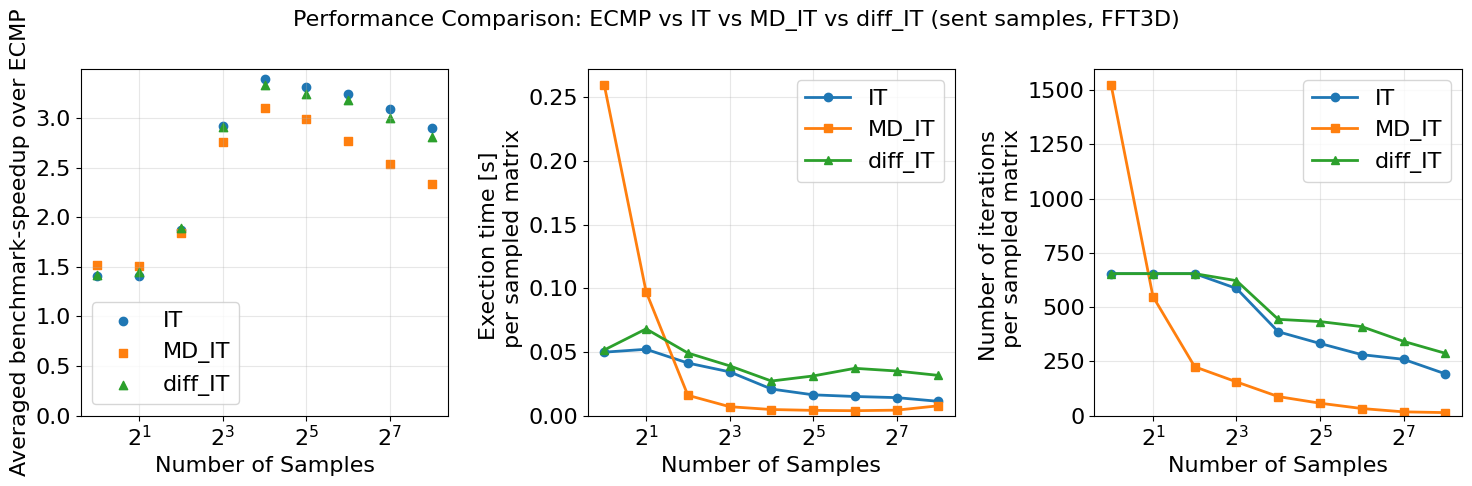


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0498s, MD_IT: 0.2595s, diff_IT: 0.0515s
  Attempts - IT: 654.00, MD_IT: 1522.00, diff_IT: 654.00

Num Samples: 2
  Time - IT: 0.0521s, MD_IT: 0.1945s, diff_IT: 0.0681s
  Attempts - IT: 654.00, MD_IT: 1097.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0412s, MD_IT: 0.0636s, diff_IT: 0.0491s
  Attempts - IT: 654.00, MD_IT: 899.00, diff_IT: 654.00

Num Samples: 8
  Time - IT: 0.0343s, MD_IT: 0.0555s, diff_IT: 0.0390s
  Attempts - IT: 585.75, MD_IT: 1241.00, diff_IT: 621.62

Num Samples: 16
  Time - IT: 0.0208s, MD_IT: 0.0755s, diff_IT: 0.0271s
  Attempts - IT: 386.12, MD_IT: 1397.00, diff_IT: 443.38

Num Samples: 32
  Time - IT: 0.0163s, MD_IT: 0.1296s, diff_IT: 0.0311s
  Attempts - IT: 332.16, MD_IT: 1817.00, diff_IT: 433.09

Num Samples: 64
  Time - IT: 0.0149s, MD_IT: 0.2429s, diff_IT: 0.0371s
  Attempts - IT: 280.67, MD_IT: 2065.00, diff_IT: 409.80

Num Samples: 128
  Time - IT: 0.0141s, MD_IT: 0.5408s, diff_IT: 0.0350s
  Attemp

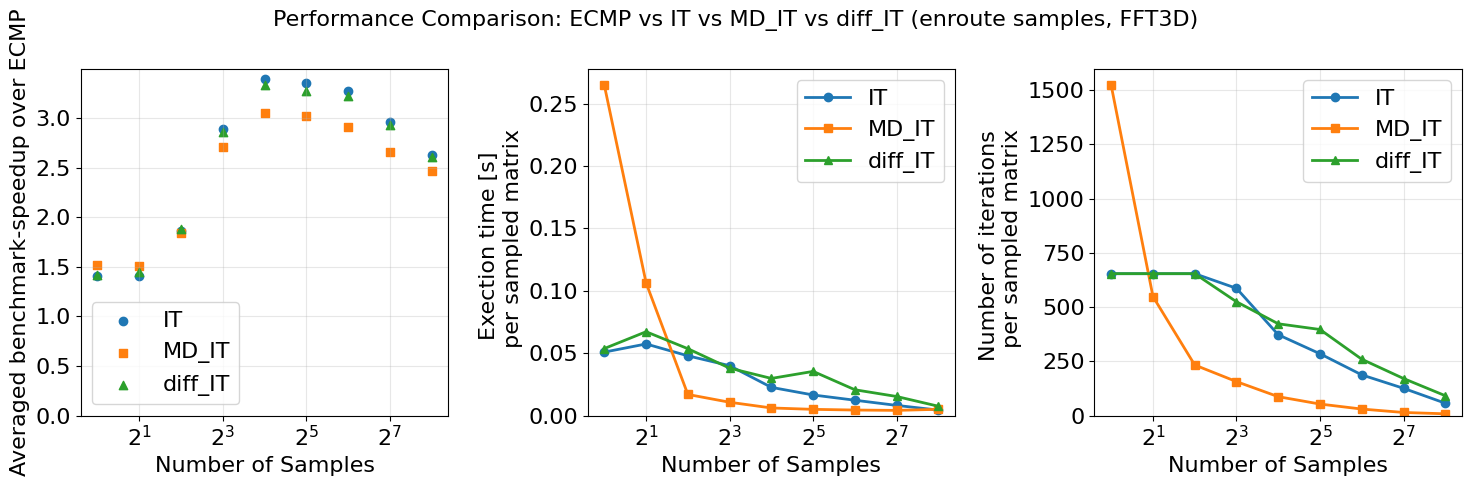


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0508s, MD_IT: 0.2647s, diff_IT: 0.0537s
  Attempts - IT: 654.00, MD_IT: 1522.00, diff_IT: 654.00

Num Samples: 2
  Time - IT: 0.0574s, MD_IT: 0.2126s, diff_IT: 0.0672s
  Attempts - IT: 654.00, MD_IT: 1097.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0479s, MD_IT: 0.0676s, diff_IT: 0.0536s
  Attempts - IT: 654.00, MD_IT: 932.00, diff_IT: 654.00

Num Samples: 8
  Time - IT: 0.0400s, MD_IT: 0.0851s, diff_IT: 0.0380s
  Attempts - IT: 586.50, MD_IT: 1251.00, diff_IT: 524.50

Num Samples: 16
  Time - IT: 0.0226s, MD_IT: 0.0970s, diff_IT: 0.0297s
  Attempts - IT: 372.44, MD_IT: 1390.00, diff_IT: 422.94

Num Samples: 32
  Time - IT: 0.0165s, MD_IT: 0.1584s, diff_IT: 0.0354s
  Attempts - IT: 284.72, MD_IT: 1692.00, diff_IT: 396.62

Num Samples: 64
  Time - IT: 0.0123s, MD_IT: 0.2814s, diff_IT: 0.0206s
  Attempts - IT: 187.38, MD_IT: 1911.00, diff_IT: 259.53

Num Samples: 128
  Time - IT: 0.0081s, MD_IT: 0.5266s, diff_IT: 0.0153s
  Attemp

In [3]:
plot_results('sent', 'FFT3D')
plot_results('enroute', 'FFT3D')

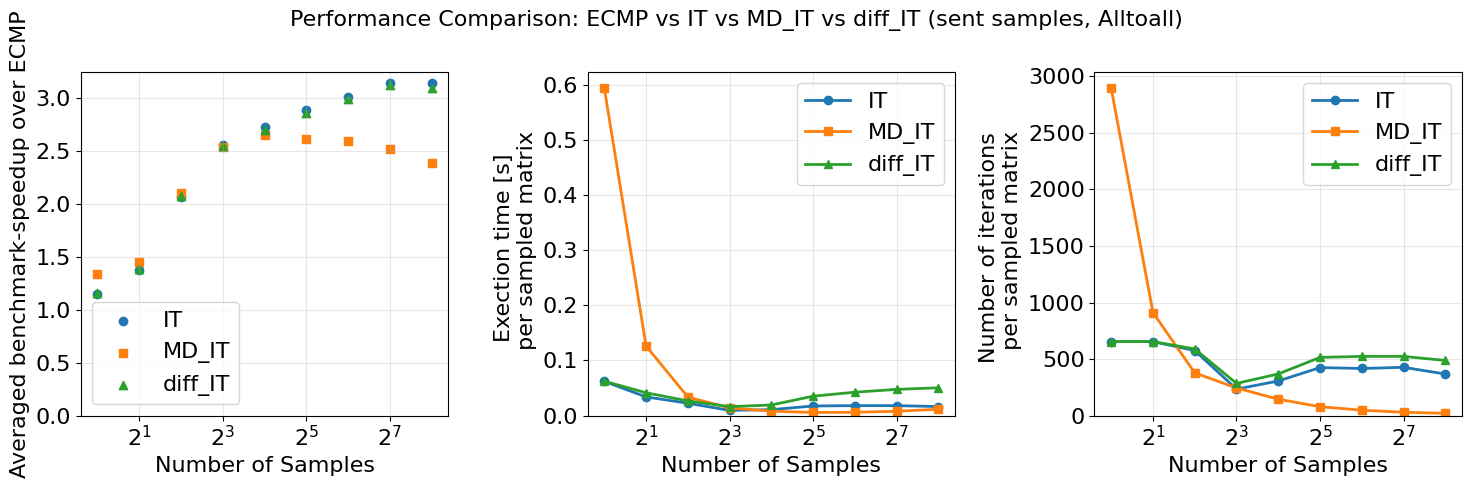


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0620s, MD_IT: 0.5946s, diff_IT: 0.0624s
  Attempts - IT: 654.00, MD_IT: 2895.00, diff_IT: 654.00

Num Samples: 2
  Time - IT: 0.0338s, MD_IT: 0.2525s, diff_IT: 0.0413s
  Attempts - IT: 654.00, MD_IT: 1823.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0224s, MD_IT: 0.1340s, diff_IT: 0.0265s
  Attempts - IT: 574.75, MD_IT: 1510.00, diff_IT: 589.25

Num Samples: 8
  Time - IT: 0.0093s, MD_IT: 0.1107s, diff_IT: 0.0161s
  Attempts - IT: 233.88, MD_IT: 1950.00, diff_IT: 283.88

Num Samples: 16
  Time - IT: 0.0107s, MD_IT: 0.1249s, diff_IT: 0.0191s
  Attempts - IT: 305.44, MD_IT: 2306.00, diff_IT: 367.94

Num Samples: 32
  Time - IT: 0.0173s, MD_IT: 0.1803s, diff_IT: 0.0351s
  Attempts - IT: 424.19, MD_IT: 2498.00, diff_IT: 514.31

Num Samples: 64
  Time - IT: 0.0180s, MD_IT: 0.3731s, diff_IT: 0.0424s
  Attempts - IT: 416.22, MD_IT: 3025.00, diff_IT: 523.17

Num Samples: 128
  Time - IT: 0.0179s, MD_IT: 0.9996s, diff_IT: 0.0475s
  Attem

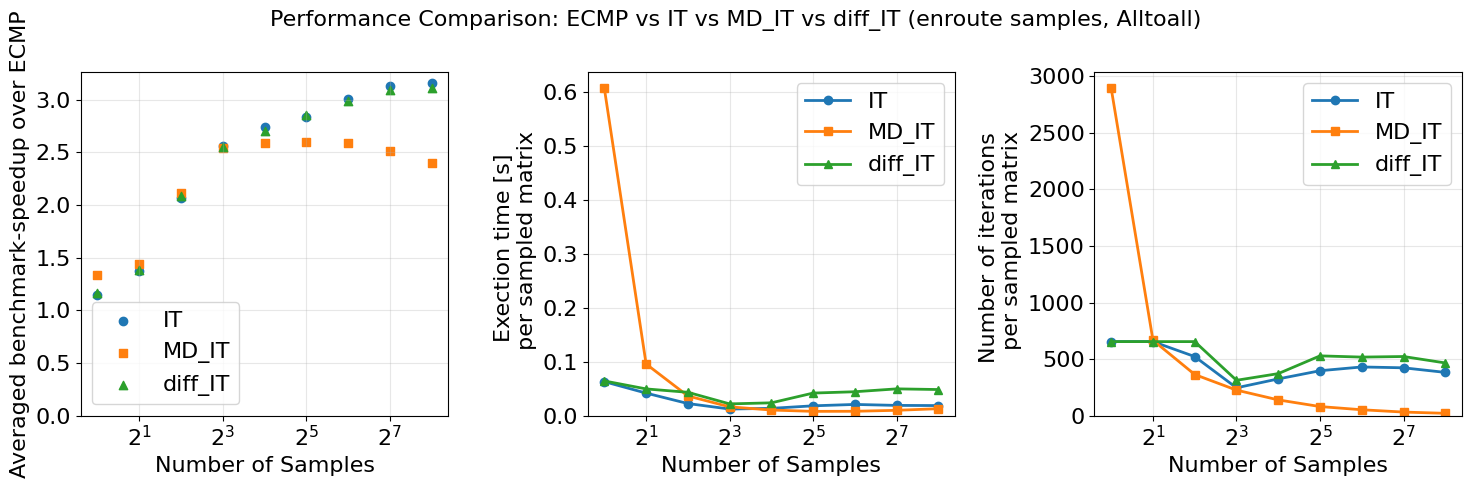


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0627s, MD_IT: 0.6064s, diff_IT: 0.0641s
  Attempts - IT: 654.00, MD_IT: 2895.00, diff_IT: 654.00

Num Samples: 2
  Time - IT: 0.0415s, MD_IT: 0.1910s, diff_IT: 0.0493s
  Attempts - IT: 654.00, MD_IT: 1332.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0222s, MD_IT: 0.1451s, diff_IT: 0.0430s
  Attempts - IT: 521.50, MD_IT: 1451.00, diff_IT: 654.00

Num Samples: 8
  Time - IT: 0.0120s, MD_IT: 0.1284s, diff_IT: 0.0215s
  Attempts - IT: 245.25, MD_IT: 1799.00, diff_IT: 311.75

Num Samples: 16
  Time - IT: 0.0133s, MD_IT: 0.1627s, diff_IT: 0.0235s
  Attempts - IT: 323.94, MD_IT: 2211.00, diff_IT: 370.75

Num Samples: 32
  Time - IT: 0.0180s, MD_IT: 0.2464s, diff_IT: 0.0416s
  Attempts - IT: 396.38, MD_IT: 2539.00, diff_IT: 527.84

Num Samples: 64
  Time - IT: 0.0205s, MD_IT: 0.5037s, diff_IT: 0.0441s
  Attempts - IT: 429.69, MD_IT: 3265.00, diff_IT: 517.00

Num Samples: 128
  Time - IT: 0.0188s, MD_IT: 1.2366s, diff_IT: 0.0494s
  Attem

In [4]:
plot_results('sent', 'Alltoall')
plot_results('enroute', 'Alltoall')

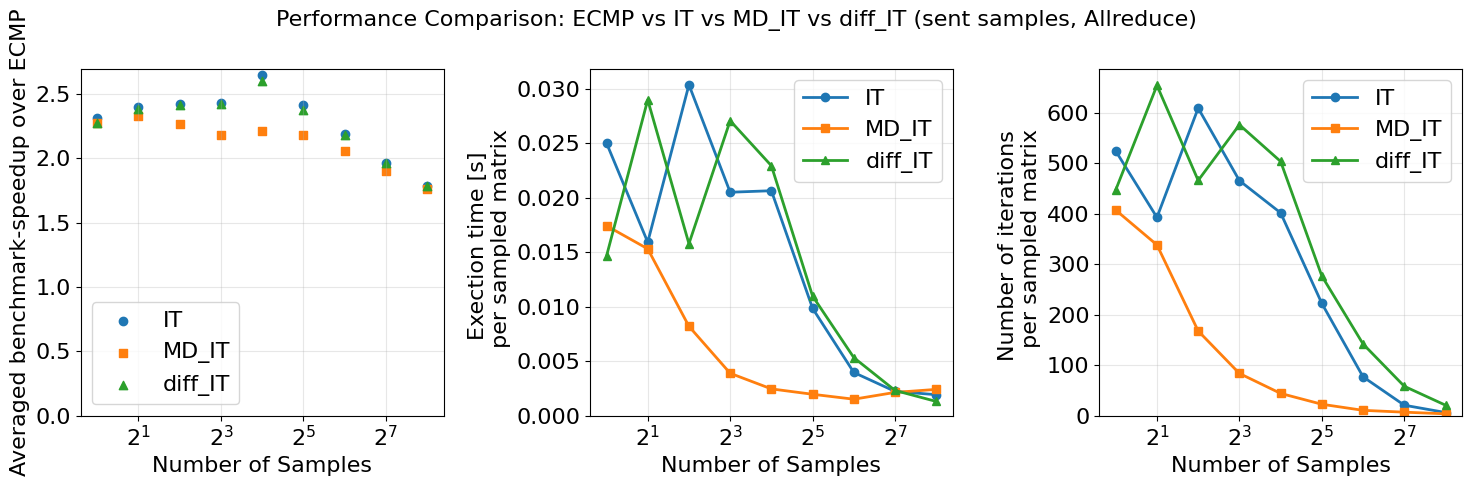


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0250s, MD_IT: 0.0174s, diff_IT: 0.0146s
  Attempts - IT: 524.00, MD_IT: 407.00, diff_IT: 447.00

Num Samples: 2
  Time - IT: 0.0159s, MD_IT: 0.0306s, diff_IT: 0.0290s
  Attempts - IT: 392.50, MD_IT: 676.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0304s, MD_IT: 0.0328s, diff_IT: 0.0158s
  Attempts - IT: 609.00, MD_IT: 670.00, diff_IT: 465.75

Num Samples: 8
  Time - IT: 0.0205s, MD_IT: 0.0310s, diff_IT: 0.0271s
  Attempts - IT: 465.38, MD_IT: 667.00, diff_IT: 576.00

Num Samples: 16
  Time - IT: 0.0206s, MD_IT: 0.0391s, diff_IT: 0.0229s
  Attempts - IT: 401.50, MD_IT: 701.00, diff_IT: 503.38

Num Samples: 32
  Time - IT: 0.0098s, MD_IT: 0.0624s, diff_IT: 0.0110s
  Attempts - IT: 222.09, MD_IT: 714.00, diff_IT: 276.41

Num Samples: 64
  Time - IT: 0.0040s, MD_IT: 0.0959s, diff_IT: 0.0053s
  Attempts - IT: 76.64, MD_IT: 658.00, diff_IT: 141.70

Num Samples: 128
  Time - IT: 0.0022s, MD_IT: 0.2719s, diff_IT: 0.0023s
  Attempts - IT

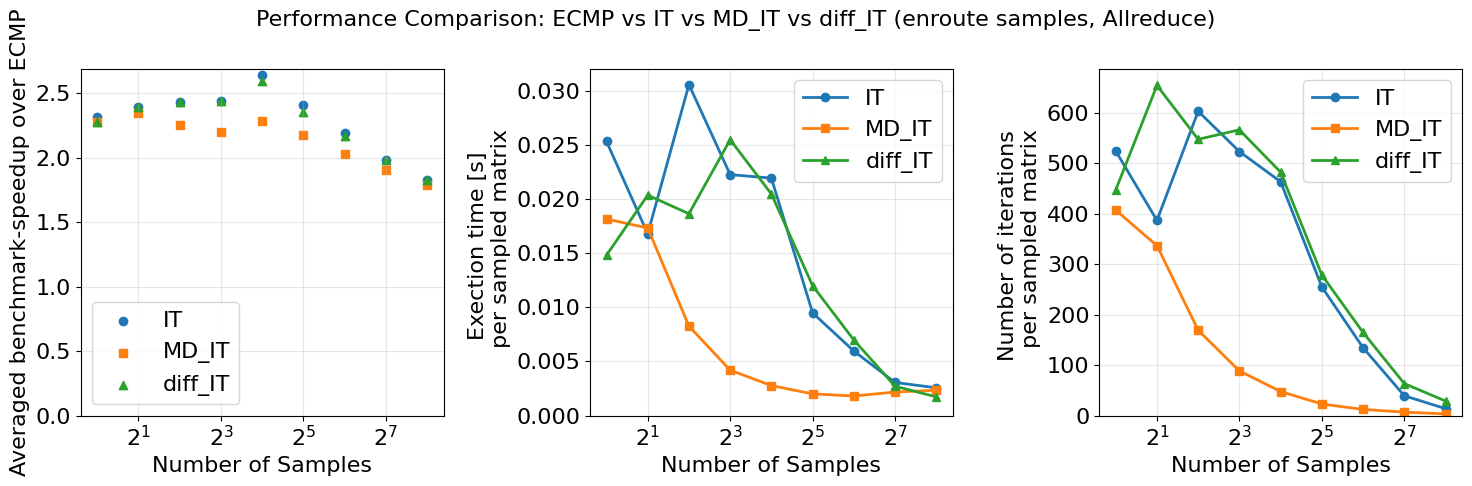


Summary Statistics:

Num Samples: 1
  Time - IT: 0.0254s, MD_IT: 0.0182s, diff_IT: 0.0148s
  Attempts - IT: 524.00, MD_IT: 407.00, diff_IT: 447.00

Num Samples: 2
  Time - IT: 0.0168s, MD_IT: 0.0347s, diff_IT: 0.0204s
  Attempts - IT: 386.50, MD_IT: 673.00, diff_IT: 654.00

Num Samples: 4
  Time - IT: 0.0306s, MD_IT: 0.0331s, diff_IT: 0.0187s
  Attempts - IT: 602.75, MD_IT: 676.00, diff_IT: 547.25

Num Samples: 8
  Time - IT: 0.0223s, MD_IT: 0.0336s, diff_IT: 0.0255s
  Attempts - IT: 523.00, MD_IT: 707.00, diff_IT: 566.00

Num Samples: 16
  Time - IT: 0.0220s, MD_IT: 0.0443s, diff_IT: 0.0205s
  Attempts - IT: 463.19, MD_IT: 760.00, diff_IT: 482.12

Num Samples: 32
  Time - IT: 0.0095s, MD_IT: 0.0640s, diff_IT: 0.0120s
  Attempts - IT: 254.81, MD_IT: 731.00, diff_IT: 278.31

Num Samples: 64
  Time - IT: 0.0060s, MD_IT: 0.1156s, diff_IT: 0.0070s
  Attempts - IT: 134.34, MD_IT: 774.00, diff_IT: 164.58

Num Samples: 128
  Time - IT: 0.0031s, MD_IT: 0.2783s, diff_IT: 0.0027s
  Attempts - I

In [5]:
plot_results('sent', 'Allreduce')
plot_results('enroute', 'Allreduce')